In [93]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import random
import math
from collections import deque
from pathlib import Path

import torch
import torch.nn as nn
import torch.optim as optim
from pairs_trading_env import PairsTradingEnv

TRAIN_RATIO  = 0.80
CSV_A = 'dataset/CORN_USD_2005_2020.csv'   # ← change to your file
CSV_B = 'dataset/WHEAT_USD_2005_2020.csv'   # ← change to your file
CSV_C = 'data-scripts/data.csv'
# ─────────────────────────────────────────────────────────────────────

df_a = pd.read_csv(CSV_A).dropna()
df_b = pd.read_csv(CSV_B).dropna()
# df_a = pd.read_csv(CSV_C)[['s1']].dropna()
# df_b = pd.read_csv(CSV_C)[['s2']].dropna()
# df_a = df_a.rename(columns={"s1": "close"})
# df_b = df_b.rename(columns={"s2": "close"})
# df_a = df_a[int(0*len(df_a)):int(len(df_a))]
# df_b = df_b[int(0*len(df_b)):int(len(df_b))]
df_a = df_a[::100]
df_b = df_b[::100]
n = len(df_a)
A = df_a['close'].values
B = df_b['close'].values

split        = int(n * TRAIN_RATIO)
X = np.column_stack([np.ones(split), B[:split]])
beta_ols, _ = np.linalg.lstsq(X, A[:split], rcond=None)[0], None
beta      = beta_ols[1]

spread = A - beta * B

spread_train = spread[:split]
spread_test = spread[split:]

print(len(spread))

10653


In [94]:
from statsmodels.tsa.regime_switching.markov_autoregression import MarkovAutoregression
k=2
import numpy as np

mu = spread_train.mean()
sigma = spread_train.std()

spread_train_sc = (spread_train - mu) / sigma
spread_test_sc  = (spread_test  - mu) / sigma   # use *train* stats, not test

res = MarkovAutoregression(spread_train_sc, k_regimes=k, order=1, switching_ar=True, switching_trend=True, switching_variance=True).fit(disp=False)

train_states = res.smoothed_marginal_probabilities.argmax(axis=1)

res_test = MarkovAutoregression(spread_test_sc, k_regimes=k, order=1).filter(res.params)
test_probs = res_test.filtered_marginal_probabilities

LinAlgError: SVD did not converge

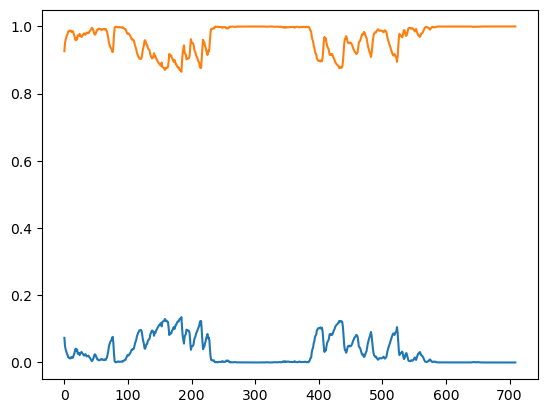

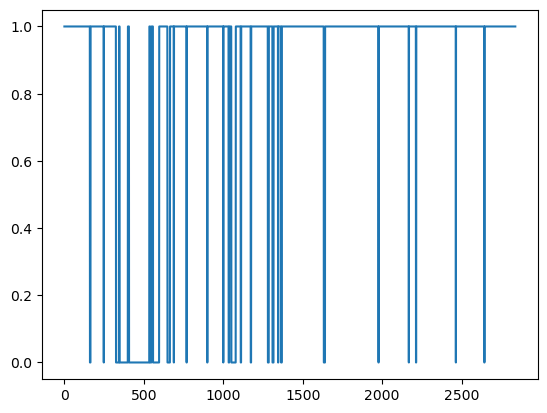

In [ ]:
plt.plot(test_probs)
plt.show()
plt.plot(train_states)
plt.show()